# Stochastic Multi-Armed Bandit with Zooming Model

This notebook demonstrates the usage of the Zooming model for quantitative action spaces with the stochastic multi-armed bandit (sMAB) implementation in `pybandits`.

The Zooming model adaptively partitions a continuous action space and fits a model (e.g., Beta) to each segment. This allows efficient exploration and exploitation in continuous or high-cardinality action spaces through an adaptive discretization approach.

References:
- [Multi-Armed Bandits in Metric Spaces (Kleinberg, Slivkins, and Upfal, 2008)](https://arxiv.org/pdf/0809.4882)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pybandits.quantitative_model import Zooming
from pybandits.smab import SmabBernoulli

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

First, we'll define actions with quantitative parameters. In this example, we'll use two actions, each with a one-dimensional quantitative parameter (e.g., price point or dosage level) ranging from 0 to 1.

In [2]:
# For reproducibility
np.random.seed(42)

# Define actions with zooming models
actions = {"action_1": Zooming.cold_start(dimension=1), "action_2": Zooming.cold_start(dimension=1)}

Now we can initialize the SmabBernoulli bandit with our zooming models:

In [3]:
# Initialize the bandit
smab = SmabBernoulli(actions=actions)

## Simulate Environment

Let's create a reward function that depends on both the action and its quantitative parameter. For illustration purposes, we'll define that:

- `action_1` has optimal parameter values around 0.25
- `action_2` has optimal parameter values around 0.75

The reward probability follows a bell curve centered around these optimal values.

In [4]:
def reward_function(action, quantity):
    if action == "action_1":
        # Bell curve centered at 0.25
        prob = np.exp(-((quantity - 0.25) ** 2) / 0.02)
    else:  # action_2
        # Bell curve centered at 0.75
        prob = np.exp(-((quantity - 0.75) ** 2) / 0.02)
    return np.random.binomial(1, prob)

Let's visualize our reward functions to understand what the bandit needs to learn:

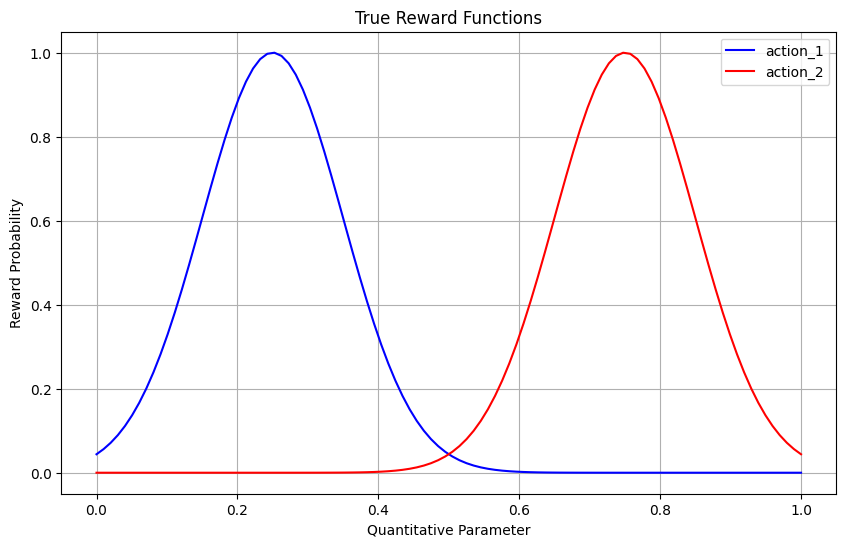

In [5]:
x = np.linspace(0, 1, 100)
y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) for xi in x]
y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) for xi in x]

plt.figure(figsize=(10, 6))
plt.plot(x, y1, "b-", label="action_1")
plt.plot(x, y2, "r-", label="action_2")
plt.xlabel("Quantitative Parameter")
plt.ylabel("Reward Probability")
plt.title("True Reward Functions")
plt.legend()
plt.grid(True)
plt.show()

## Bandit Training Loop

Now, let's train our bandit by simulating interactions for several rounds:

In [6]:
n_rounds = 500
history = []

for t in range(n_rounds):
    # Sample random quantities to be evaluated for each action
    # In a real-world scenario, these might be potential price points to test

    # Predict best action (n_samples=1)
    pred_actions, probs = smab.predict(n_samples=1)
    chosen_action = pred_actions[0][0]
    chosen_quantity = pred_actions[0][1][0]

    # Observe reward
    reward = reward_function(chosen_action, chosen_quantity)

    # Update bandit
    smab.update(actions=[chosen_action], rewards=[reward], quantities=[chosen_quantity])

    # Store history
    history.append((t, chosen_action, chosen_quantity, reward))

## Analyze Results

Let's visualize the bandit's learning process and choices over time:

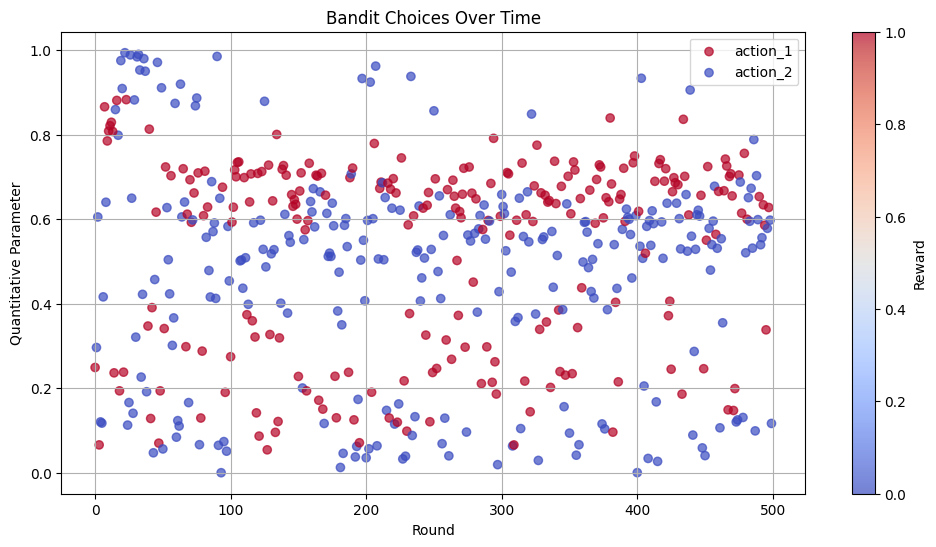

In [7]:
# Extract data from history
rounds = [h[0] for h in history]
actions_hist = [h[1] for h in history]
quantities_hist = [h[2] for h in history]
rewards_hist = [h[3] for h in history]

# Create a scatter plot of chosen quantities over time
plt.figure(figsize=(12, 6))
colors = {"action_1": "blue", "action_2": "red"}
for action in np.unique(actions_hist):
    mask = [a == action for a in actions_hist]
    plt.scatter(
        [rounds[i] for i in range(len(mask)) if mask[i]],
        [quantities_hist[i] for i in range(len(mask)) if mask[i]],
        c=[rewards_hist[i] for i in range(len(mask)) if mask[i]],
        cmap="coolwarm",
        alpha=0.7,
        label=action,
    )

plt.xlabel("Round")
plt.ylabel("Quantitative Parameter")
plt.title("Bandit Choices Over Time")
plt.legend()
plt.colorbar(label="Reward")
plt.grid(True)
plt.show()

Let's look at the distribution of choices in the last 100 rounds, when the bandit has had time to learn:

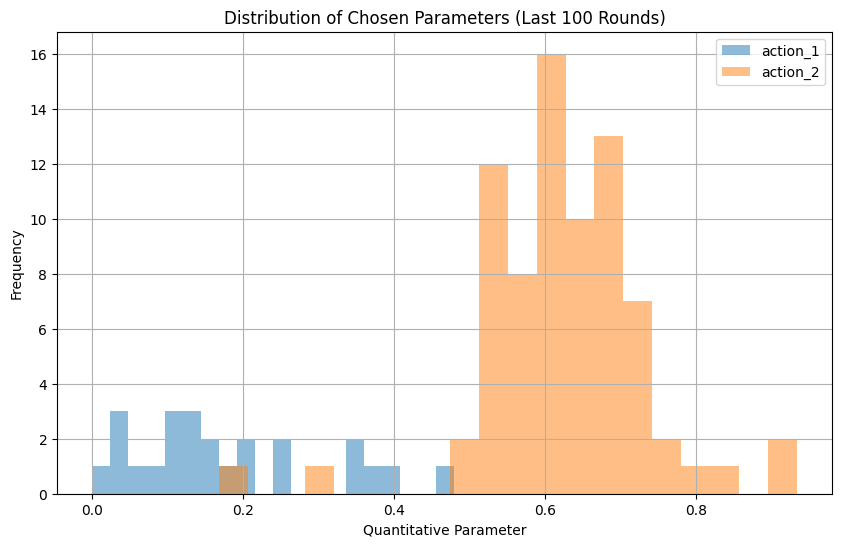

In [8]:
# Analyze the last 100 rounds
last_100_actions = actions_hist[-100:]
last_100_quantities = quantities_hist[-100:]

plt.figure(figsize=(10, 6))

# Plot histogram of quantitative parameters for each action
for action in np.unique(actions_hist):
    action_quantities = [last_100_quantities[i] for i in range(100) if last_100_actions[i] == action]
    if action_quantities:
        plt.hist(action_quantities, bins=20, alpha=0.5, label=action)

plt.xlabel("Quantitative Parameter")
plt.ylabel("Frequency")
plt.title("Distribution of Chosen Parameters (Last 100 Rounds)")
plt.legend()
plt.grid(True)
plt.show()

## Reward Performance Over Time

Let's analyze how the reward performance improves as the bandit learns:

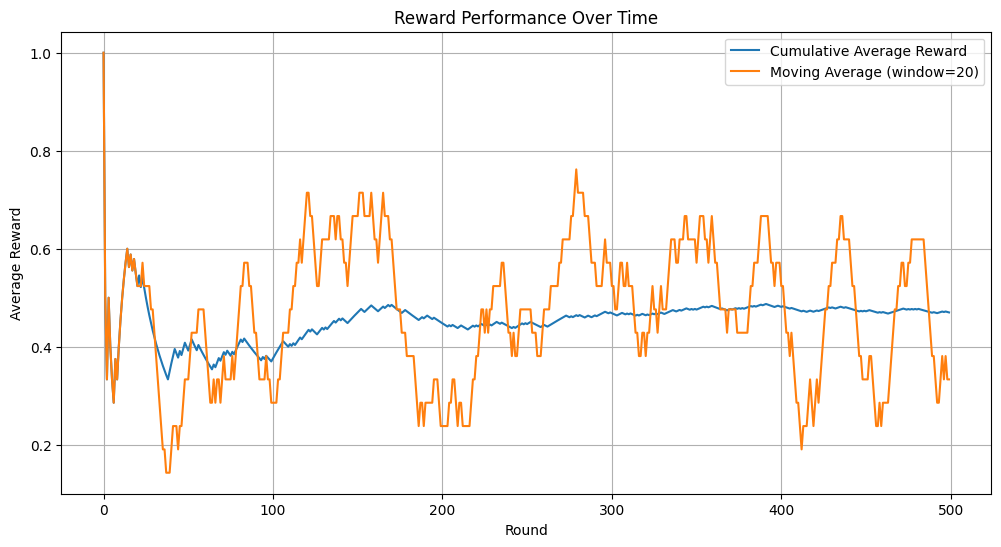

In [9]:
# Calculate cumulative average reward
cumulative_reward = np.cumsum(rewards_hist)
cumulative_avg_reward = [cumulative_reward[i] / (i + 1) for i in range(len(cumulative_reward))]

# Calculate moving average with window=20
window_size = 20
moving_avg = [np.mean(rewards_hist[max(0, i - window_size) : i + 1]) for i in range(len(rewards_hist))]

plt.figure(figsize=(12, 6))
plt.plot(cumulative_avg_reward, label="Cumulative Average Reward")
plt.plot(moving_avg, label=f"Moving Average (window={window_size})")
plt.xlabel("Round")
plt.ylabel("Average Reward")
plt.title("Reward Performance Over Time")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

The Zooming model with sMAB allows efficient exploration and exploitation of continuous action parameters. It adaptively refines the segmentation of the parameter space, concentrating more segments in high-reward regions for finer discretization.

This approach is particularly useful when:
1. Actions have continuous parameters that affect rewards
2. The reward function is unknown and needs to be learned
3. The optimal parameter values may vary across different actions

Real-world applications include pricing optimization, dose finding in medicine, or any scenario involving continuous parameter tuning.